## Curve fitting for four Hypro and WP4C samples

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [4]:
filename = '../data/water_retention_curve_wet_and_dry.xlsx'
df = pd.read_excel(filename)
df

,sample_id,pF,matric_kPa,water_content_vol%,theta_cm3cm-3,conductivity_log10K(cm/d),hidraulic_conductivity,log_matric
0,8965,-0.31,0.048978,55.89,0.5600,NaN,NaN,-1.31
1,8965,0.01,0.102329,55.81,0.5600,NaN,NaN,-0.99
2,8965,0.28,0.190546,55.69,0.5600,NaN,NaN,-0.72
3,8965,0.48,0.301995,55.58,0.5600,NaN,NaN,-0.52
4,8965,0.60,0.398107,55.48,0.5500,NaN,NaN,-0.40
...,...,...,...,...,...,...,...,...
426,11269,4.48,3019.951720,11.82,0.1182,NaN,NaN,3.48
427,11269,3.88,758.577575,17.06,0.1706,NaN,NaN,2.88
428,11269,3.92,831.763771,16.17,0.1617,NaN,NaN,2.92
429,11269,4.17,1479.108388,13.74,0.1374,NaN,NaN,3.17


In [4]:
idx_remove = df['sample_id'] == 8965
df = df.drop(df[idx_remove].index)
df.reset_index(inplace=True, drop=True)

In [5]:
# Fit van Genuchten model
xdata = df["matric_kPa"]
ydata = df["theta_cm3cm-3"]
#p0 = [0.002, 1.5, 1, 0.05, 0.5]
lb = [0, 1, 0, 0.35]
ub = [1, 5, 0.25, 0.55]
bounds=(lb,ub)
model = lambda x, alpha, n, theta_r, theta_s: theta_r + (theta_s-theta_r)*(1+(alpha*x)**n)**-(1-1/n)
par_opt, par_cov = curve_fit(model, xdata, ydata, bounds=bounds)
print(par_opt)


[0.53878558 1.35550149 0.095348   0.53485426]


In [6]:
# Compute mean absolute error
mae = np.mean(np.abs(model(df['matric_kPa'], *par_opt) - df['theta_cm3cm-3']))
mae

0.006221233098132892

In [7]:
# Create boolen for each sample so that we can plot them in individual scatter plots
df['sample_id'].unique()
idx_11255 = df['sample_id'] == 11255
idx_11266 = df['sample_id'] == 11266
idx_11269 = df['sample_id'] == 11269


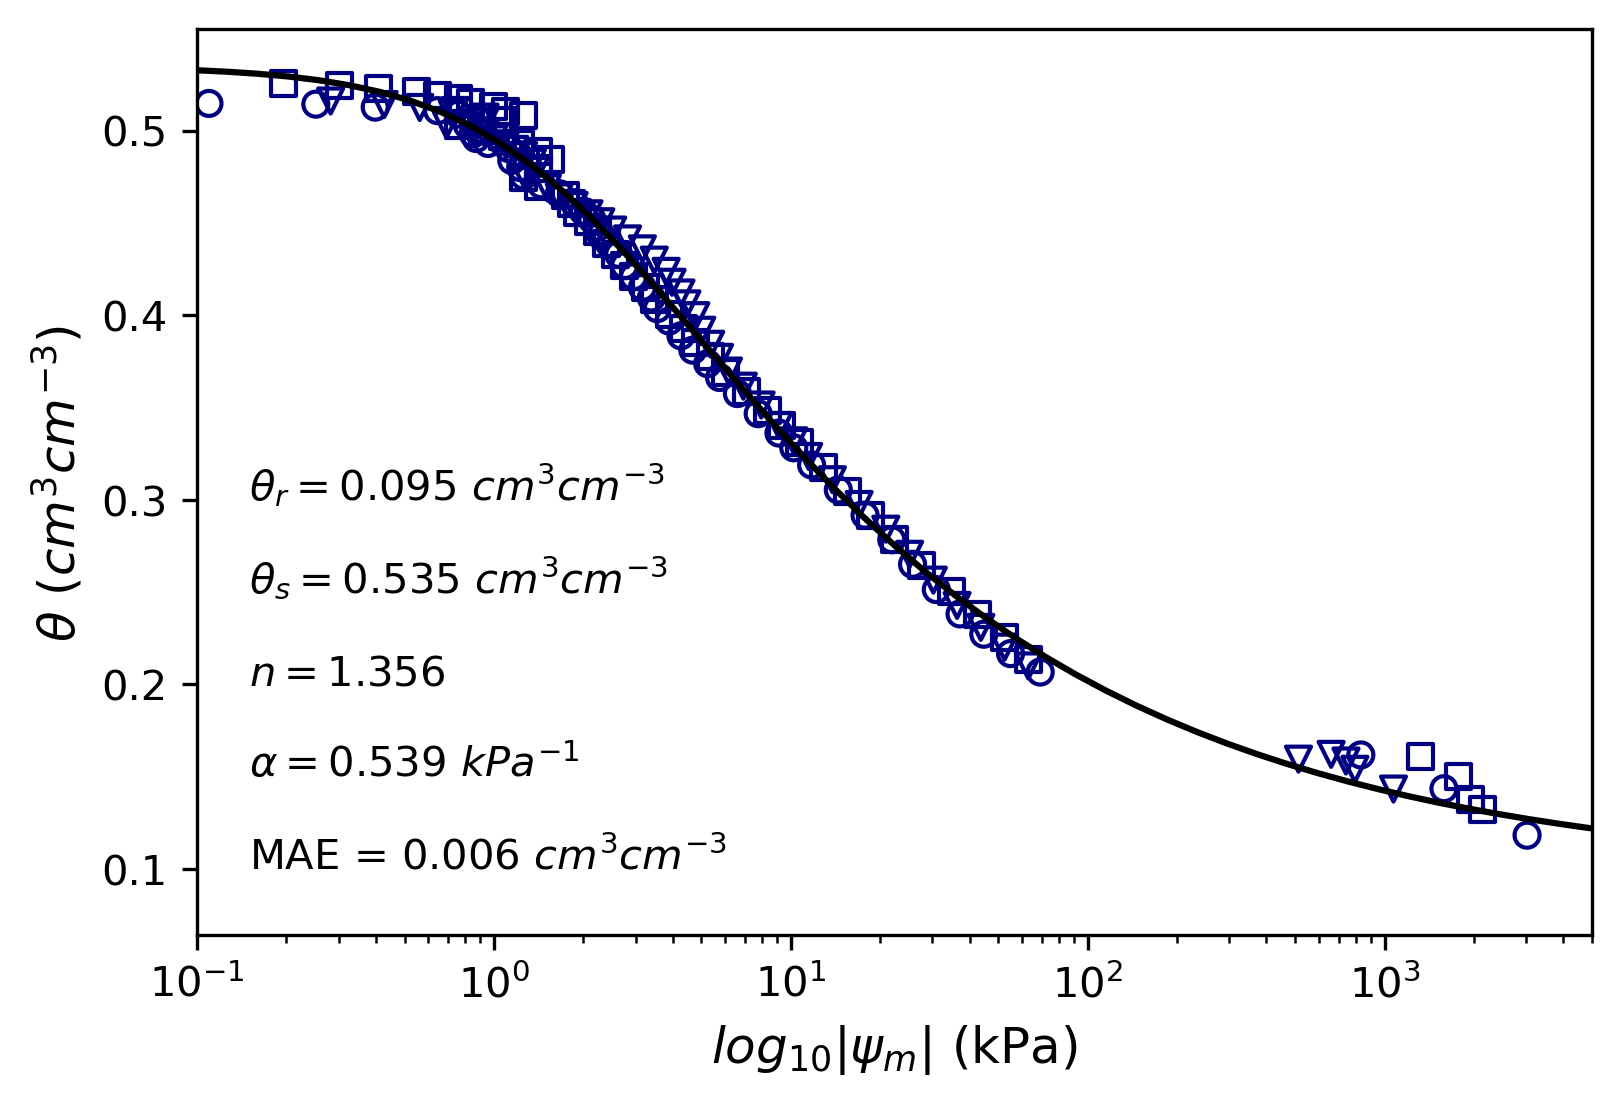

In [16]:
# Plot observations and fitted model

# Observations
plt.figure(figsize=(6, 4), dpi=300)
plt.scatter(df.loc[idx_11255,"matric_kPa"][::2], df.loc[idx_11255,"theta_cm3cm-3"][::2],
            facecolor='None', edgecolor='navy', marker='s')
plt.scatter(df.loc[idx_11266,"matric_kPa"][::2], df.loc[idx_11266,"theta_cm3cm-3"][::2],
            facecolor='None', edgecolor='navy', marker='v')
plt.scatter(df.loc[idx_11269,"matric_kPa"][::2], df.loc[idx_11269,"theta_cm3cm-3"][::2],
            facecolor='None', edgecolor='navy', marker='o')


# Model
x_model = np.logspace(-1,4)
y_model = model(x_model, *par_opt)
plt.plot(x_model, y_model, color='black')

# Annotations
plt.text(0.15,0.3,'$ \\theta_r = 0.095 \ cm^3 cm^{-3} $', size=10)
plt.text(0.15,0.25,'$ \\theta_s = 0.535 \ cm^3 cm^{-3} $', size=10)
plt.text(0.15,0.2,'$ n = 1.356 $', size=10)
plt.text(0.15,0.15,'$ \\alpha = 0.539 \ kPa^{-1} $', size=10)
plt.text(0.15,0.1,'MAE = 0.006 $cm^3 cm^{-3}$', size=10)

plt.xscale(value='log')
plt.xlim(0.1, 5000)
plt.xlabel('$log_{10}|\psi_m|$ (kPa)', size=12)
plt.ylabel('$ \\theta \ (cm^3 cm^{-3})$', size=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)


plt.savefig('../figures/soil_water_retention_curve.jpg', dpi=300,  transparent=False)
plt.show()